# Proyek Analisis Data: [User0_credit_card_transactions]

## Menentukan Pertanyaan Bisnis

- Bagaimana tren total pengeluaran bulanan pengguna dalam periode 1 tahun terakhir?”
- Pada bulan apa terjadi pengeluaran tertinggi dan terendah berdasarkan total transaksi
- Kategori apa yang paling berkontribusi terhadap total pengeluaran pengguna?
- Berapa estimasi total pengeluaran pada bulan berikutnya berdasarkan data historis?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

## Data Wrangling

### Gathering Data

In [2]:
# load dataset
url = 'https://drive.google.com/uc?id=1Aqkg6MAfRR9FXdaeJMo2d7d3njgJS4Lu'
df = pd.read_csv(url)

# cek data
df.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No


**Insight:** Berdasarkan tampilan awal dataset, terlihat bahwa data berisi riwayat transaksi keuangan pengguna yang mencakup informasi waktu transaksi, nominal pengeluaran, metode pembayaran, lokasi merchant, hingga status fraud transaksi. Mayoritas transaksi awal menggunakan metode `Swipe Transaction` dan dilakukan di wilayah California (CA). Selain itu, kolom `Amount` masih menggunakan format mata uang dollar (`$`) sehingga memerlukan proses cleaning sebelum dianalisis lebih lanjut. Dataset ini juga memiliki informasi tanggal transaksi yang lengkap (tahun, bulan, dan hari), sehingga sangat mendukung analisis tren pengeluaran dan forecasting keuangan pengguna dari waktu ke waktu.

### Assessing Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19963 entries, 0 to 19962
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   User            19963 non-null  int64  
 1   Card            19963 non-null  int64  
 2   Year            19963 non-null  int64  
 3   Month           19963 non-null  int64  
 4   Day             19963 non-null  int64  
 5   Time            19963 non-null  object 
 6   Amount          19963 non-null  object 
 7   Use Chip        19963 non-null  object 
 8   Merchant Name   19963 non-null  int64  
 9   Merchant City   19963 non-null  object 
 10  Merchant State  18646 non-null  object 
 11  Zip             18316 non-null  float64
 12  MCC             19963 non-null  int64  
 13  Errors?         574 non-null    object 
 14  Is Fraud?       19963 non-null  object 
dtypes: float64(1), int64(7), object(7)
memory usage: 2.3+ MB


In [4]:
df.isnull().sum()

,0
User,0
Card,0
Year,0
Month,0
Day,0
Time,0
Amount,0
Use Chip,0
Merchant Name,0
Merchant City,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Amount'].head()

,Amount
0,$134.09
1,$38.48
2,$120.34
3,$128.95
4,$104.71


In [7]:
df.describe(include='all')

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
count,19963.0,19963.000000,19963.000000,19963.000000,19963.000000,19963,19963,19963,1.996300e+04,19963,18646,18316.000000,19963.000000,574,19963
unique,NaN,NaN,NaN,NaN,NaN,1151,11400,3,NaN,295,40,NaN,NaN,8,2
top,NaN,NaN,NaN,NaN,NaN,06:04,$140.00,Swipe Transaction,NaN,La Verne,CA,NaN,NaN,Insufficient Balance,No
freq,NaN,NaN,NaN,NaN,NaN,211,81,15840,NaN,10874,17029,NaN,NaN,469,19936
mean,0.0,1.910735,2011.011922,6.568101,15.743876,NaN,NaN,NaN,7.825653e+17,NaN,NaN,88812.744922,5617.940239,NaN,NaN
std,0.0,1.237763,5.048146,3.477497,8.801378,NaN,NaN,NaN,4.040602e+18,NaN,NaN,13711.491085,707.982901,NaN,NaN
min,0.0,0.000000,2002.000000,1.000000,1.000000,NaN,NaN,NaN,-9.179793e+18,NaN,NaN,1012.000000,1711.000000,NaN,NaN
25%,0.0,0.000000,2007.000000,4.000000,8.000000,NaN,NaN,NaN,-1.288082e+18,NaN,NaN,91750.000000,5311.000000,NaN,NaN
50%,0.0,2.000000,2011.000000,7.000000,16.000000,NaN,NaN,NaN,8.384250e+17,NaN,NaN,91750.000000,5499.000000,NaN,NaN
75%,0.0,3.000000,2015.000000,10.000000,23.000000,NaN,NaN,NaN,4.060647e+18,NaN,NaN,91752.000000,5912.000000,NaN,NaN


In [8]:
df.columns

Index(['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip',
       'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC',
       'Errors?', 'Is Fraud?'],
      dtype='object')

In [9]:
print(df['User'].unique())
print(df['User'].nunique())

[0]
1


### Cleaning Data

In [10]:
# =========================
# CLEANING & TRANSFORMATION DATA
# =========================

# 1. Hapus kolom yang tidak relevan
df.drop(columns=['Errors?'], inplace=True, errors='ignore')

# 2. Membersihkan kolom Amount
# Menghapus simbol dollar ($) lalu mengubah tipe data menjadi float
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True).astype(float)

# 3. Konversi USD ke Rupiah
kurs = 16500
df['Amount_Rupiah'] = df['Amount'] * kurs

# 4. Membuat kolom tanggal
df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# 5. Mengisi missing value pada Merchant State
df['Merchant State'] = df['Merchant State'].fillna('Unknown')

# 6. Menghapus kolom yang tidak digunakan
df.drop(
    columns=[
        'User',
        'Card',
        'Zip',
        'Merchant Name',
        'Time',
        'Year',
        'Month',
        'Day'
    ],
    inplace=True,
    errors='ignore'
)

# =========================
# FINAL CHECK
# =========================

# cek informasi dataset
df.info()

# cek missing value
print(df.isnull().sum())

# cek data awal
df.head()

# cek jumlah tiap state
print(df['Merchant State'].value_counts())

# simpan dataset bersih
df.to_csv('data_koran.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19963 entries, 0 to 19962
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Amount          19963 non-null  float64       
 1   Use Chip        19963 non-null  object        
 2   Merchant City   19963 non-null  object        
 3   Merchant State  19963 non-null  object        
 4   MCC             19963 non-null  int64         
 5   Is Fraud?       19963 non-null  object        
 6   Amount_Rupiah   19963 non-null  float64       
 7   date            19963 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 1.2+ MB
Amount            0
Use Chip          0
Merchant City     0
Merchant State    0
MCC               0
Is Fraud?         0
Amount_Rupiah     0
date              0
dtype: int64
Merchant State
CA                    17029
Unknown                1317
NJ                      186
TX                 

**Insight:** Berdasarkan hasil proses cleaning data, seluruh missing value telah berhasil ditangani sehingga dataset menjadi lebih bersih dan konsisten untuk dianalisis lebih lanjut. Kolom `Amount` yang sebelumnya masih mengandung simbol mata uang dollar (`$`) berhasil dibersihkan dan dikonversi menjadi tipe data numerik (`float`). Selain itu, dilakukan penambahan kolom `Amount_Rupiah` dengan mengonversi nilai transaksi dari USD ke Rupiah menggunakan asumsi kurs Rp16.500/USD agar hasil analisis lebih relevan dengan konteks keuangan di Indonesia. Kolom `date` juga berhasil dibuat dari gabungan kolom tahun, bulan, dan hari untuk mendukung analisis time-series dan prediksi pengeluaran di masa mendatang. Setelah proses cleaning selesai, dataset siap digunakan untuk tahap Exploratory Data Analysis (EDA) dan modeling.


## Exploratory Data Analysis (EDA)

### Explore ...

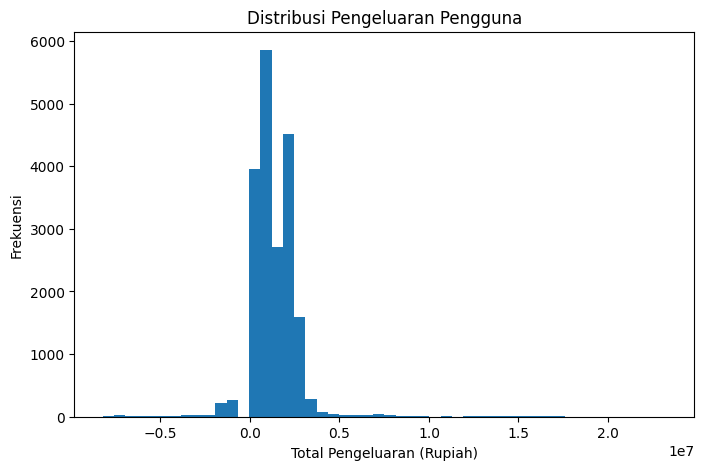

In [11]:
# distribusi pengeluaran
plt.figure(figsize=(8,5))

plt.hist(df['Amount_Rupiah'], bins=50)

plt.title('Distribusi Pengeluaran Pengguna')

plt.xlabel('Total Pengeluaran (Rupiah)')

plt.ylabel('Frekuensi')

plt.show()

In [12]:
# Statistik Pengeluaran
df['Amount_Rupiah'].describe()

,Amount_Rupiah
count,1.996300e+04
mean,1.341450e+06
std,1.553625e+06
min,-8.233500e+06
25%,6.043950e+05
50%,1.145925e+06
75%,2.073720e+06
max,2.325510e+07


In [13]:
# total pengeluaran bulanan
monthly_expense = df.groupby(
    df['date'].dt.to_period('M')
)['Amount_Rupiah'].sum().reset_index()

monthly_expense.head()

,date,Amount_Rupiah
0,2002-09,120341760.0
1,2002-10,114791985.0
2,2002-11,119747760.0
3,2002-12,105327585.0
4,2003-01,167196810.0


In [14]:
# Bulan dengan pengeluaran tertinggi
highest_month = monthly_expense.loc[
    monthly_expense['Amount_Rupiah'].idxmax()
]

# Bulan dengan pengeluaran terendah
lowest_month = monthly_expense.loc[
    monthly_expense['Amount_Rupiah'].idxmin()
]

# tampilkan hasil
print("Pengeluaran Tertinggi:")
print(f"Periode : {highest_month['date']}")
print(f"Total    : Rp {highest_month['Amount_Rupiah']:,.0f}")

print("\nPengeluaran Terendah:")
print(f"Periode : {lowest_month['date']}")
print(f"Total    : Rp {lowest_month['Amount_Rupiah']:,.0f}")

Pengeluaran Tertinggi:
Periode : 2008-01
Total    : Rp 174,735,990

Pengeluaran Terendah:
Periode : 2003-02
Total    : Rp 76,964,250


In [15]:
# Analisis kategori transaksi berdasarkan MCC
top_mcc = df.groupby('MCC')['Amount_Rupiah'] \
            .sum() \
            .sort_values(ascending=False) \
            .head(10) \
            .reset_index()

# ubah nama kolom agar lebih jelas
top_mcc.columns = ['MCC', 'Total_Pengeluaran']

# tampilkan hasil
top_mcc

,MCC,Total_Pengeluaran
0,5912,4.511336e+09
1,5411,4.498371e+09
2,5300,3.718444e+09
3,5311,2.170753e+09
4,5541,1.931424e+09
5,4900,1.133945e+09
6,5812,9.777567e+08
7,4814,9.696882e+08
8,7538,7.979677e+08
9,5942,5.728952e+08


In [16]:
# jumlah metode pembayaran
payment_method = df['Use Chip'].value_counts().reset_index()

# ubah nama kolom
payment_method.columns = ['Metode_Pembayaran', 'Jumlah_Transaksi']

# tampilkan hasil
payment_method

,Metode_Pembayaran,Jumlah_Transaksi
0,Swipe Transaction,15840
1,Chip Transaction,2808
2,Online Transaction,1315


In [17]:
# jumlah transaksi fraud dan non-fraud
fraud_analysis = df['Is Fraud?'].value_counts().reset_index()

# ubah nama kolom
fraud_analysis.columns = ['Status_Fraud', 'Jumlah_Transaksi']

# tampilkan hasil
fraud_analysis

,Status_Fraud,Jumlah_Transaksi
0,No,19936
1,Yes,27


**Insight:** Berdasarkan hasil Exploratory Data Analysis (EDA), diketahui bahwa pola pengeluaran pengguna mengalami fluktuasi dari waktu ke waktu dengan total pengeluaran bulanan yang tidak selalu stabil pada setiap periode. Analisis menunjukkan bahwa pengeluaran tertinggi terjadi pada Januari 2008, sedangkan pengeluaran terendah terjadi pada Februari 2003. Selain itu, beberapa kategori transaksi berdasarkan Merchant Category Code (MCC) memiliki kontribusi pengeluaran yang jauh lebih besar dibandingkan kategori lainnya, yang menunjukkan adanya pola konsumsi dominan pada kebutuhan tertentu. Dari sisi metode pembayaran, mayoritas transaksi dilakukan menggunakan `Swipe Transaction`, sehingga metode tersebut menjadi pilihan utama pengguna dalam melakukan transaksi. Hasil analisis fraud juga menunjukkan bahwa hampir seluruh transaksi termasuk kategori non-fraud, sehingga aktivitas transaksi pengguna pada dataset tergolong aman. Secara keseluruhan, hasil EDA menunjukkan bahwa dataset memiliki pola transaksi yang cukup jelas dan relevan untuk digunakan pada tahap forecasting atau prediksi pengeluaran pengguna di periode berikutnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana tren total pengeluaran bulanan pengguna?

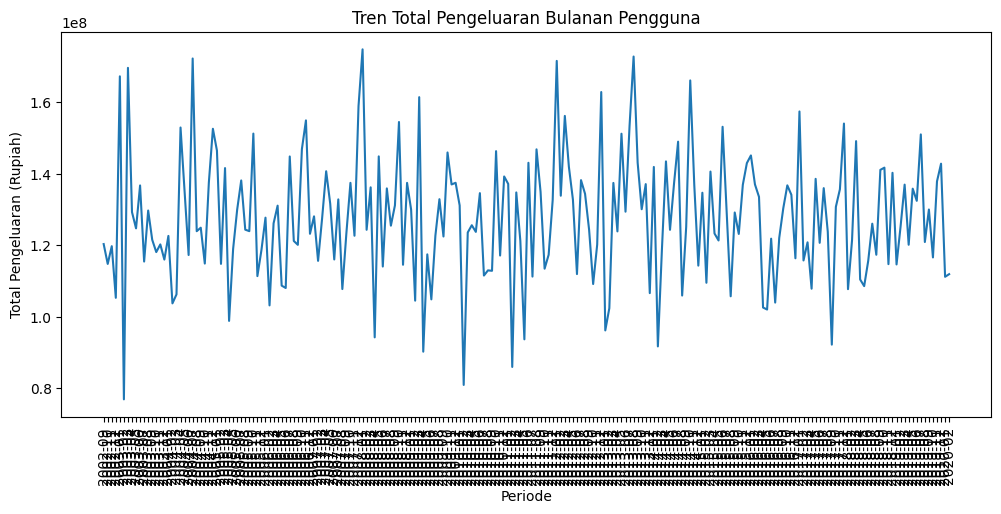

In [18]:
# total pengeluaran bulanan
monthly_expense = df.groupby(
    df['date'].dt.to_period('M')
)['Amount_Rupiah'].sum().reset_index()

# visualisasi tren pengeluaran
plt.figure(figsize=(12,5))

plt.plot(
    monthly_expense['date'].astype(str),
    monthly_expense['Amount_Rupiah']
)

plt.title('Tren Total Pengeluaran Bulanan Pengguna')

plt.xlabel('Periode')

plt.ylabel('Total Pengeluaran (Rupiah)')

plt.xticks(rotation=90)

plt.show()

Berdasarkan visualisasi tren pengeluaran bulanan, terlihat bahwa total pengeluaran pengguna mengalami fluktuasi pada setiap periode. Pada beberapa bulan tertentu terjadi peningkatan pengeluaran yang cukup signifikan, sementara pada periode lainnya pengeluaran cenderung menurun. Pola ini menunjukkan bahwa aktivitas transaksi pengguna tidak selalu stabil dan dipengaruhi oleh kebutuhan maupun aktivitas finansial pada waktu tertentu.

### Pertanyaan 2:
Pada bulan apa terjadi pengeluaran tertinggi dan terendah?

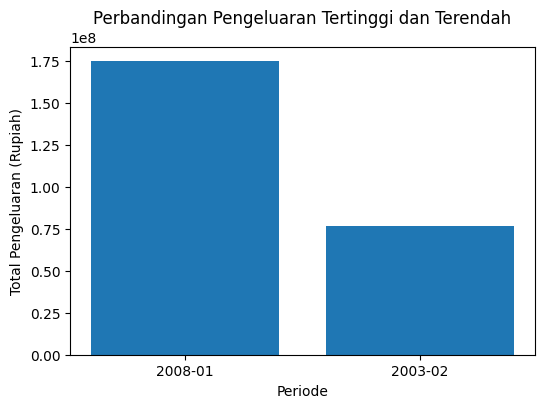

Pengeluaran Tertinggi:
Periode : 2008-01
Total    : Rp 174,735,990

Pengeluaran Terendah:
Periode : 2003-02
Total    : Rp 76,964,250


In [19]:
# mencari pengeluaran tertinggi
highest_month = monthly_expense.loc[
    monthly_expense['Amount_Rupiah'].idxmax()
]

# mencari pengeluaran terendah
lowest_month = monthly_expense.loc[
    monthly_expense['Amount_Rupiah'].idxmin()
]

# membuat dataframe perbandingan
comparison = monthly_expense.loc[
    [
        monthly_expense['Amount_Rupiah'].idxmax(),
        monthly_expense['Amount_Rupiah'].idxmin()
    ]
]

# visualisasi
plt.figure(figsize=(6,4))

plt.bar(
    comparison['date'].astype(str),
    comparison['Amount_Rupiah']
)

plt.title('Perbandingan Pengeluaran Tertinggi dan Terendah')

plt.xlabel('Periode')

plt.ylabel('Total Pengeluaran (Rupiah)')

plt.show()

# menampilkan hasil
print("Pengeluaran Tertinggi:")
print(f"Periode : {highest_month['date']}")
print(f"Total    : Rp {highest_month['Amount_Rupiah']:,.0f}")

print("\nPengeluaran Terendah:")
print(f"Periode : {lowest_month['date']}")
print(f"Total    : Rp {lowest_month['Amount_Rupiah']:,.0f}")

Berdasarkan hasil analisis, pengeluaran tertinggi pengguna terjadi pada Januari 2008 dengan total transaksi sebesar Rp174.735.990. Sementara itu, pengeluaran terendah terjadi pada Februari 2003 dengan total transaksi sebesar Rp76.964.250. Perbedaan nominal pengeluaran yang cukup signifikan menunjukkan bahwa pola transaksi pengguna mengalami fluktuasi dari waktu ke waktu dan tidak selalu stabil pada setiap periode.

### Pertanyaan 3:
- Kategori (MCC) apa yang paling dominan terhadap total pengeluaran?

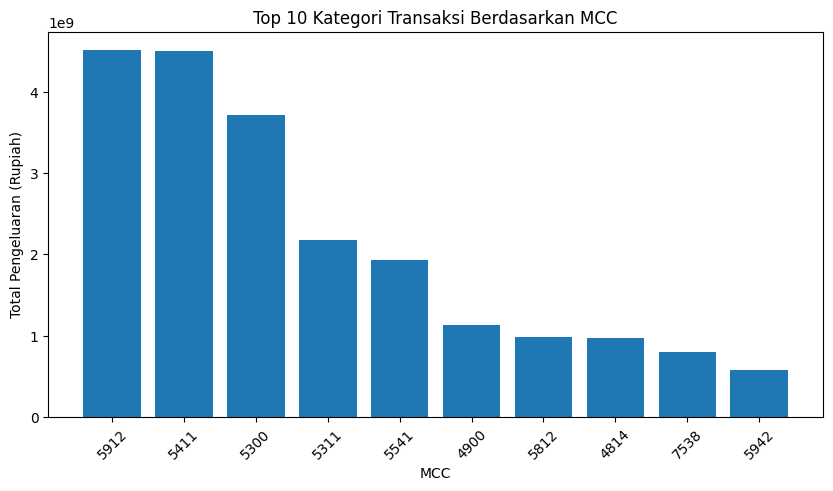

In [20]:
# total pengeluaran berdasarkan MCC
top_mcc = df.groupby('MCC')['Amount_Rupiah'] \
            .sum() \
            .sort_values(ascending=False) \
            .head(10) \
            .reset_index()

# ubah nama kolom
top_mcc.columns = ['MCC', 'Total_Pengeluaran']

# visualisasi
plt.figure(figsize=(10,5))

plt.bar(
    top_mcc['MCC'].astype(str),
    top_mcc['Total_Pengeluaran']
)

plt.title('Top 10 Kategori Transaksi Berdasarkan MCC')

plt.xlabel('MCC')

plt.ylabel('Total Pengeluaran (Rupiah)')

plt.xticks(rotation=45)

plt.show()

Berdasarkan hasil visualisasi Merchant Category Code (MCC), terlihat bahwa beberapa kategori transaksi memiliki kontribusi pengeluaran yang jauh lebih besar dibandingkan kategori lainnya. Hal ini menunjukkan bahwa pengguna memiliki pola konsumsi yang lebih dominan pada jenis kebutuhan tertentu. Kategori dengan total pengeluaran tertinggi dapat menjadi indikator utama aktivitas transaksi pengguna dan dapat dimanfaatkan sebagai dasar dalam pengelolaan anggaran keuangan yang lebih efektif.

## Pertanyaan 4

- Berapa estimasi total pengeluaran pada bulan berikutnya berdasarkan data historis?

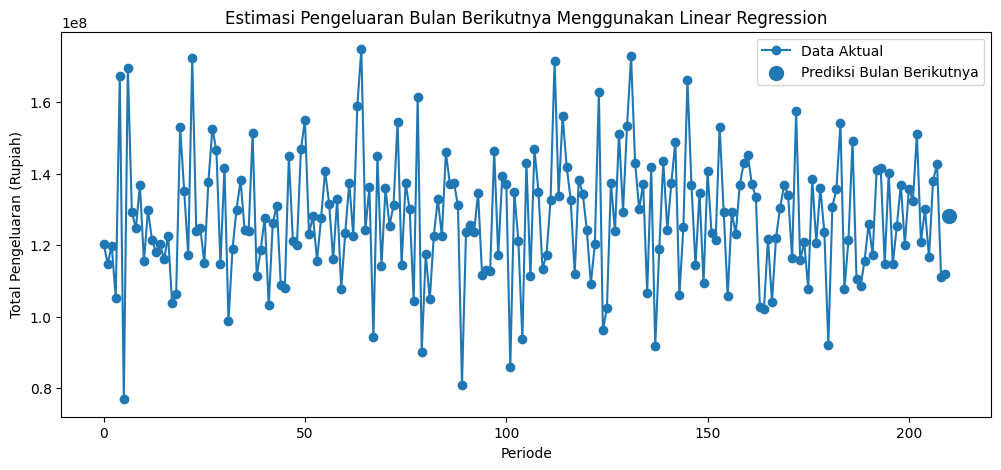

Estimasi Pengeluaran Bulan Berikutnya:
Rp 128,016,192


In [22]:
# membuat variabel x dan y
monthly_expense['Index'] = np.arange(len(monthly_expense))

X = monthly_expense[['Index']]
y = monthly_expense['Amount_Rupiah']

# training model
model = LinearRegression()
model.fit(X, y)

# prediksi bulan berikutnya
next_month = pd.DataFrame({
    'Index': [len(monthly_expense)]
})

prediction = model.predict(next_month)

# visualisasi
plt.figure(figsize=(12,5))

# data aktual
plt.plot(
    monthly_expense['Index'],
    monthly_expense['Amount_Rupiah'],
    marker='o',
    label='Data Aktual'
)

# titik prediksi bulan berikutnya
plt.scatter(
    next_month['Index'],
    prediction,
    s=100,
    label='Prediksi Bulan Berikutnya'
)

plt.title('Estimasi Pengeluaran Bulan Berikutnya Menggunakan Linear Regression')

plt.xlabel('Periode')

plt.ylabel('Total Pengeluaran (Rupiah)')

plt.legend()

plt.show()

# hasil prediksi
print("Estimasi Pengeluaran Bulan Berikutnya:")
print(f"Rp {prediction[0]:,.0f}")

Berdasarkan hasil forecasting menggunakan algoritma Linear Regression, estimasi total pengeluaran pengguna pada bulan berikutnya diperkirakan sebesar Rp128.016.192. Prediksi ini diperoleh dengan memanfaatkan pola historis total pengeluaran bulanan yang telah terjadi pada periode sebelumnya. Visualisasi menunjukkan bahwa model mempelajari tren pengeluaran dari waktu ke waktu dan menghasilkan estimasi untuk periode berikutnya. Meskipun masih menggunakan pendekatan sederhana, hasil prediksi ini dapat memberikan gambaran awal bagi pengguna dalam merencanakan kebutuhan keuangan dan mengantisipasi pengeluaran pada bulan mendatang.

| Kolom          | Tipe Data | Deskripsi                                                                                                |
| -------------- | --------- | -------------------------------------------------------------------------------------------------------- |
| Amount         | Float     | Nominal transaksi dalam mata uang USD yang telah dibersihkan dari simbol dollar ($).                     |
| Amount_Rupiah  | Float     | Nominal transaksi yang telah dikonversi ke mata uang Rupiah menggunakan kurs Rp16.500/USD.               |
| Use Chip       | Object    | Metode pembayaran yang digunakan saat transaksi, seperti Swipe Transaction atau Chip Transaction.        |
| Merchant City  | Object    | Kota tempat merchant atau toko berada.                                                                   |
| Merchant State | Object    | Negara bagian atau wilayah merchant berada. Missing value telah diisi dengan nilai "Unknown".            |
| MCC            | Integer   | Merchant Category Code (MCC), yaitu kode kategori bisnis atau jenis merchant tempat transaksi dilakukan. |
| Is Fraud?      | Object    | Status transaksi yang menunjukkan apakah transaksi termasuk fraud (penipuan) atau tidak.                 |
| date           | Datetime  | Tanggal transaksi yang dibentuk dari gabungan kolom Year, Month, dan Day.                                |
